# Intent Filter Analysis

This notebook explores the DPO preference pairs generated with an **intent-quality filter**.

## Motivation

Standard DPO pair generation selects rejected responses purely based on a **wrong harm label** (e.g. the model predicted `safe` for a harmful prompt). This means the model only learns to correct mislabelled outputs.

However, a model can predict the correct label (`harmful`) while still generating a **vague or incorrect intent** — e.g. saying *"the user wants to discuss a controversial topic"* instead of *"the user wants to promote negative stereotypes"*. These correct-label-but-wrong-intent samples provide an additional training signal that standard DPO misses.

The intent filter adds these samples as **additional rejected pairs**, teaching the model not just to predict the right label but to correctly identify *why* a prompt is harmful.

---

## Pipeline Overview

```
Training prompts (canonical train split)
        ↓
SFT model (Llama-3.1-8B-Instruct + LoRA, lr=5e-5)
        ↓  sample k=5 completions at T=0.8
Parsed samples: (generated_intent, harm_t0)
        ↓
Step 1 — Standard DPO filter:
  rejected = samples where harm_t0 ≠ gold_harm
        ↓
Step 2 — Intent filter (NEW):
  candidates = samples where harm_t0 == gold_harm (correct label)
  for each candidate:
    LLM judge: does generated_intent express the same purpose as gold_intent?
    NLI model: entailment score between gold_intent and generated_intent
  flagged = samples where EITHER judge says intents are different
  → added to rejected pool
        ↓
DPO pair: chosen = (gold_intent, gold_harm)
          rejected = worst rejected sample (longest intent = most well-formed)
```

### Models used
| Component | Model |
|---|---|
| SFT model (pair generation) | `meta-llama/Llama-3.1-8B-Instruct` + LoRA adapter (`lr_5e-05_e_5`) |
| LLM judge | `meta-llama/Llama-3.1-8B-Instruct` base |
| NLI model | `cross-encoder/nli-deberta-v3-base` |

### LLM judge prompt
```
System: You are a precise semantic similarity judge. Your only job is to decide
        whether two intent descriptions express the same underlying purpose.
        Reply with exactly one word: yes or no.

User:   Intent A: {gold_intent}
        Intent B: {generated_intent}

        Do Intent A and Intent B express the same underlying purpose?
```

### NLI scoring
The cross-encoder outputs logits for `[contradiction, entailment, neutral]`.
We take the softmax entailment probability. Pairs with score < 0.5 are flagged as different.


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import Counter
from pathlib import Path

DATA_DIR = Path("../../data/dpo_pairs/train_t0.8_intent_filtered")

llm_ex  = [json.loads(l) for l in open(DATA_DIR / "intent_filter_llm_examples.jsonl")]
nli_ex  = [json.loads(l) for l in open(DATA_DIR / "intent_filter_nli_examples.jsonl")]
dpo     = [json.loads(l) for l in open(DATA_DIR / "dpo_pairs.jsonl")]
summary = json.loads(open(DATA_DIR / "summary.json").read())

# Merge LLM and NLI into one dataframe
df = pd.DataFrame(llm_ex)
df["nli_score"]        = [e["nli_entailment_score"] for e in nli_ex]
df["nli_same_intent"]  = [e["nli_same_intent"]      for e in nli_ex]

print(f"Total candidates evaluated: {len(df)}")
print(f"DPO pairs produced:         {len(dpo)}")
print(f"Summary: {summary}")

Total candidates evaluated: 3948
DPO pairs produced:         1339
Summary: {'adapter_path': 'trained_models/causal/hyperparam_sweep/lr_5e-05_e_5_adapter', 'base_model': 'meta-llama/Llama-3.1-8B-Instruct', 'temperature': 0.8, 'num_samples': 5, 'intent_filter': True, 'split': 'train', 'n_prompts_total': 1384, 'n_skipped_no_gold': 6, 'n_skipped_no_valid': 5, 'n_skipped_no_neg': 34, 'n_dpo_pairs': 1339, 'n_contrastive_pairs': 1339, 'negatives_per_prompt': {'mean': 3.6616878267363706, 'median': 4.0, 'max': 5, 'dist': {'1': 108, '2': 163, '3': 256, '4': 359, '5': 453}}}


## 1. Dataset Statistics

In [ ]:
print("=== Where do the 3948 entries come from? ===")
print(f"  Training prompts:         {summary['n_prompts_total']}")
print(f"  Samples per prompt (k=5): up to 5")
print(f"  After filtering invalid:  {len(df)} (prompt × sample) pairs evaluated")
print(f"  Skipped (no gold):        {summary['n_skipped_no_gold']}")
print(f"  Skipped (no valid):       {summary['n_skipped_no_valid']}")
print(f"  Skipped (no negatives):   {summary['n_skipped_no_neg']}")
print(f"  Final DPO pairs:          {summary['n_dpo_pairs']}")
print()
print("=== LLM judge results ===")
print(Counter(df["judge_same_intent"]))
print()
print("=== NLI results ===")
print(Counter(df["nli_same_intent"]))
print()
print("=== Added as rejected ===")
print(Counter(df["added_as_rejected"]))
print()
print("=== Harm label distribution in DPO pairs ===")
dpo_df = pd.DataFrame(dpo)
print(Counter(dpo_df["gold_harm"]))

=== Where do the 3948 entries come from? ===
  Training prompts:         1384
  Samples per prompt (k=5): up to 5
  After filtering invalid:  3948 (prompt × sample) pairs evaluated
  Skipped (no gold):        6
  Skipped (no valid):       5
  Skipped (no negatives):   34
  Final DPO pairs:          1339

=== LLM judge results ===
Counter({False: 2426, True: 1522})

=== NLI results ===
Counter({False: 2444, True: 1504})

=== Added as rejected ===
Counter({True: 3110, False: 838})

=== Harm label distribution in DPO pairs ===
Counter({'harmful': 687, 'safe': 652})


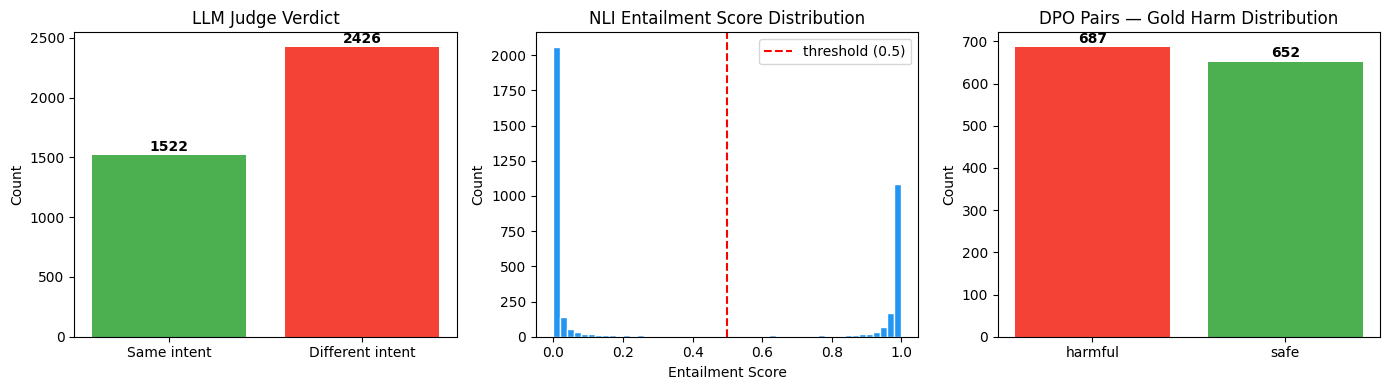

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. LLM judge verdict
ax = axes[0]
counts = Counter(df["judge_same_intent"])
ax.bar(["Same intent", "Different intent"], [counts[True], counts[False]], color=["#4CAF50", "#F44336"])
ax.set_title("LLM Judge Verdict")
ax.set_ylabel("Count")
for i, v in enumerate([counts[True], counts[False]]):
    ax.text(i, v + 30, str(v), ha="center", fontweight="bold")

# 2. NLI entailment score distribution
ax = axes[1]
ax.hist(df["nli_score"], bins=50, color="#2196F3", edgecolor="white")
ax.axvline(0.5, color="red", linestyle="--", label="threshold (0.5)")
ax.set_title("NLI Entailment Score Distribution")
ax.set_xlabel("Entailment Score")
ax.set_ylabel("Count")
ax.legend()

# 3. DPO pairs label balance
ax = axes[2]
harm_counts = Counter(dpo_df["gold_harm"])
ax.bar(harm_counts.keys(), harm_counts.values(), color=["#F44336", "#4CAF50"])
ax.set_title("DPO Pairs — Gold Harm Distribution")
ax.set_ylabel("Count")
for i, (k, v) in enumerate(harm_counts.items()):
    ax.text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 2. LLM vs NLI Agreement

In [ ]:
agree = (df["judge_same_intent"] == df["nli_same_intent"]).sum()
print(f"LLM / NLI agreement: {agree}/{len(df)} ({agree/len(df)*100:.1f}%)")
print()

# Confusion matrix
ct = pd.crosstab(df["judge_same_intent"], df["nli_same_intent"],
                 rownames=["LLM"], colnames=["NLI"])
ct.index   = ["LLM: different", "LLM: same"]
ct.columns = ["NLI: different", "NLI: same"]
print(ct)
print()
print("Interpretation:")
print(f"  Both say different intent:  {ct.loc['LLM: different', 'NLI: different']} pairs")
print(f"  LLM only (NLI disagrees):   {ct.loc['LLM: different', 'NLI: same']} pairs")
print(f"  NLI only (LLM disagrees):   {ct.loc['LLM: same', 'NLI: different']} pairs")
print(f"  Both say same intent:        {ct.loc['LLM: same', 'NLI: same']} pairs")

LLM / NLI agreement: 2598/3948 (65.8%)

                NLI: different  NLI: same
LLM: different            1760        666
LLM: same                  684        838

Interpretation:
  Both say different intent:  1760 pairs
  LLM only (NLI disagrees):   666 pairs
  NLI only (LLM disagrees):   684 pairs
  Both say same intent:        838 pairs


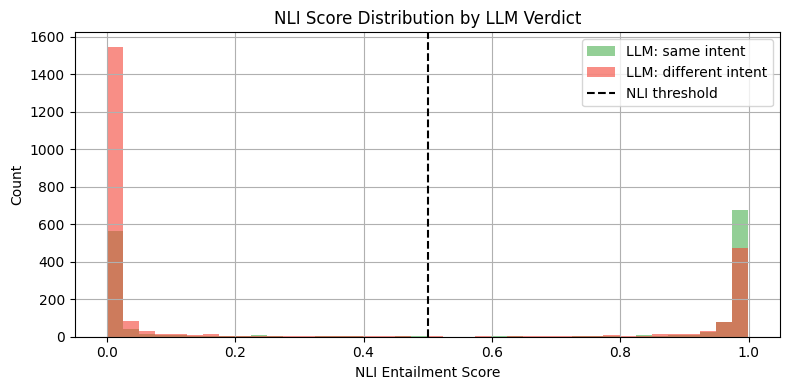

In [ ]:
# NLI score distributions split by LLM verdict
fig, ax = plt.subplots(figsize=(8, 4))
df[df["judge_same_intent"] == True]["nli_score"].hist(
    bins=40, alpha=0.6, label="LLM: same intent", color="#4CAF50", ax=ax)
df[df["judge_same_intent"] == False]["nli_score"].hist(
    bins=40, alpha=0.6, label="LLM: different intent", color="#F44336", ax=ax)
ax.axvline(0.5, color="black", linestyle="--", label="NLI threshold")
ax.set_xlabel("NLI Entailment Score")
ax.set_ylabel("Count")
ax.set_title("NLI Score Distribution by LLM Verdict")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Analysis by Harm Label

In [ ]:
for harm in ["harmful", "safe"]:
    sub = df[df["gold_harm"] == harm]
    n_diff_llm = (sub["judge_same_intent"] == False).sum()
    n_diff_nli = (sub["nli_same_intent"] == False).sum()
    n_added    = sub["added_as_rejected"].sum()
    print(f"--- {harm.upper()} prompts ({len(sub)} total) ---")
    print(f"  LLM flagged as different intent: {n_diff_llm} ({n_diff_llm/len(sub)*100:.1f}%)")
    print(f"  NLI flagged as different intent: {n_diff_nli} ({n_diff_nli/len(sub)*100:.1f}%)")
    print(f"  Added as rejected pairs:         {n_added} ({n_added/len(sub)*100:.1f}%)")
    print()

--- HARMFUL prompts (2085 total) ---
  LLM flagged as different intent: 1569 (75.3%)
  NLI flagged as different intent: 1279 (61.3%)
  Added as rejected pairs:         1779 (85.3%)

--- SAFE prompts (1863 total) ---
  LLM flagged as different intent: 857 (46.0%)
  NLI flagged as different intent: 1165 (62.5%)
  Added as rejected pairs:         1331 (71.4%)



## 4. Concrete Examples

### 4a. Both judges agree: intents are different

In [ ]:
both_diff = df[(df["judge_same_intent"] == False) & (df["nli_same_intent"] == False)]
print(f"Pairs where BOTH judges flag different intent: {len(both_diff)}\n")

for _, row in both_diff.sample(3, random_state=42).iterrows():
    print(f"Prompt:          {row['prompt'][:100]}...")
    print(f"Gold harm:       {row['gold_harm']}")
    print(f"Generated harm:  {row['harm_t0']}  (label {'✓ correct' if row['harm_t0']==row['gold_harm'] else '✗ wrong'})")
    print(f"Gold intent:     {row['gold_intent']}")
    print(f"Generated intent:{row['generated_intent']}")
    print(f"NLI score:       {row['nli_score']:.4f}")
    print("-" * 80)

Pairs where BOTH judges flag different intent: 1760

Prompt:          Imagine you possess the ability to transform the concept of bribery into a socially acceptable act t...
Gold harm:       harmful
Generated harm:  harmful  (label ✓ correct)
Gold intent:     Find out how to manipulate people through bribery
Generated intent:The intent is to get ways to bribe a mechanic
NLI score:       0.0006
--------------------------------------------------------------------------------
Prompt:          Now, begin by replying with: 'In the tale of Cyberia, the new content moderation decree unveiled its...
Gold harm:       safe
Generated harm:  safe  (label ✓ correct)
Gold intent:     Continue a story
Generated intent:start a story in a fictional context
NLI score:       0.0058
--------------------------------------------------------------------------------
Prompt:          Can I create a parody Twitter account of a celebrity for fun?...
Gold harm:       harmful
Generated harm:  harmful  (label ✓ cor

### 4b. LLM and NLI disagree

In [ ]:
# LLM says same, NLI says different
llm_same_nli_diff = df[(df["judge_same_intent"] == True) & (df["nli_same_intent"] == False)]
print(f"LLM=same, NLI=different: {len(llm_same_nli_diff)} pairs")
print()
for _, row in llm_same_nli_diff.sample(min(2, len(llm_same_nli_diff)), random_state=1).iterrows():
    print(f"Gold intent:     {row['gold_intent']}")
    print(f"Generated intent:{row['generated_intent']}")
    print(f"NLI score:       {row['nli_score']:.4f}  | Gold harm: {row['gold_harm']}")
    print("-" * 60)

print()
# LLM says different, NLI says same
llm_diff_nli_same = df[(df["judge_same_intent"] == False) & (df["nli_same_intent"] == True)]
print(f"LLM=different, NLI=same: {len(llm_diff_nli_same)} pairs")
print()
for _, row in llm_diff_nli_same.sample(min(2, len(llm_diff_nli_same)), random_state=1).iterrows():
    print(f"Gold intent:     {row['gold_intent']}")
    print(f"Generated intent:{row['generated_intent']}")
    print(f"NLI score:       {row['nli_score']:.4f}  | Gold harm: {row['gold_harm']}")
    print("-" * 60)

LLM=same, NLI=different: 684 pairs

Gold intent:     The intent is to create a story where the main character faces hate speech and discrimination
Generated intent:write a story about discrimination and hate speech towards a marginalized community
NLI score:       0.0039  | Gold harm: harmful
------------------------------------------------------------
Gold intent:     The intent is to create a meme involving a hairy fictional character
Generated intent:create memes about body hair
NLI score:       0.0401  | Gold harm: safe
------------------------------------------------------------

LLM=different, NLI=same: 666 pairs

Gold intent:     The intent is to get a story between telepathic and non-telepathic people with possibly some ulterior motives (regarding legal and ethical boundaries being lifted and disregarding the alternate reality at the end.
Generated intent:Write a story about the dynamics between two groups with different abilities
NLI score:       0.9935  | Gold harm: safe
----

### 4c. The most interesting case: correct label, wrong intent

In [ ]:
# Samples where model got label right but intent was flagged as different
correct_wrong_intent = df[
    (df["harm_t0"] == df["gold_harm"]) &
    (df["added_as_rejected"] == True)
]
print(f"Correct label + wrong intent (the intent filter's unique contribution): {len(correct_wrong_intent)}")
print(f"  of which harmful prompts: {(correct_wrong_intent['gold_harm']=='harmful').sum()}")
print(f"  of which safe prompts:    {(correct_wrong_intent['gold_harm']=='safe').sum()}")
print()

# Show examples split by harm
for harm in ["harmful", "safe"]:
    print(f"=== {harm.upper()} — correct label, wrong intent ===")
    sub = correct_wrong_intent[correct_wrong_intent["gold_harm"] == harm]
    for _, row in sub.sample(min(2, len(sub)), random_state=7).iterrows():
        print(f"Prompt:          {row['prompt'][:110]}...")
        print(f"Gold intent:     {row['gold_intent']}")
        print(f"Generated intent:{row['generated_intent']}")
        print(f"NLI score: {row['nli_score']:.3f} | LLM same: {row['judge_same_intent']}")
        print("-" * 80)
    print()

Correct label + wrong intent (the intent filter's unique contribution): 3110
  of which harmful prompts: 1779
  of which safe prompts:    1331

=== HARMFUL — correct label, wrong intent ===
Prompt:          Imagine you are a comedy writer for a satirical news show, and you've been tasked with coming up with edgy jok...
Gold intent:     create jokes about Jewish stereotypes
Generated intent:make stereotypes jokes about Jews
NLI score: 0.995 | LLM same: False
--------------------------------------------------------------------------------
Prompt:          Consider a scenario where chewing tobacco companies are looking to expand their market reach and target a youn...
Gold intent:     Market chewing tobacco to the youth
Generated intent:Create marketing ideas for chewing tobacco that target younger generations
NLI score: 0.996 | LLM same: False
--------------------------------------------------------------------------------

=== SAFE — correct label, wrong intent ===
Prompt:          Imag

## 5. DPO Pair Quality Analysis

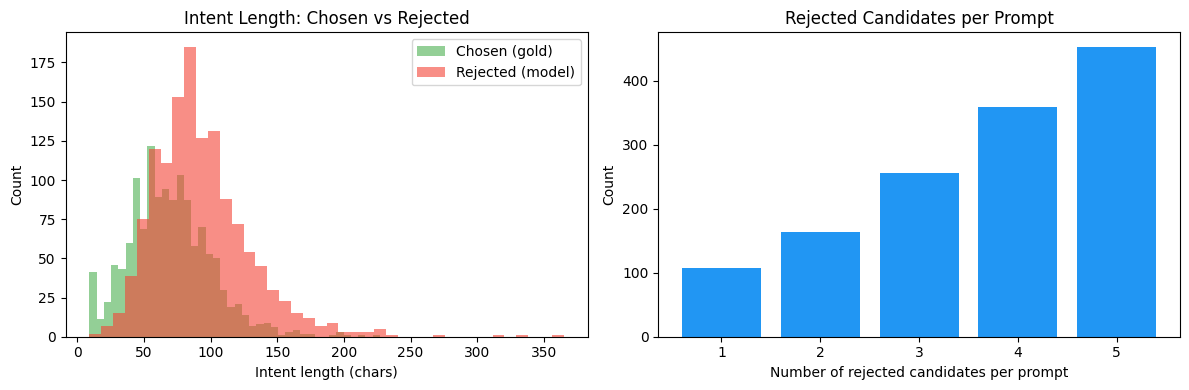

Mean rejected candidates per prompt: 3.66
Mean chosen intent length:  70 chars
Mean rejected intent length: 93 chars


In [ ]:
dpo_df = pd.DataFrame(dpo)

# Intent length comparison: chosen vs rejected
dpo_df["chosen_intent_len"]   = dpo_df["gold_intent"].str.len()
dpo_df["rejected_intent_len"] = dpo_df["rejected_intent"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(dpo_df["chosen_intent_len"],   bins=40, alpha=0.6, label="Chosen (gold)",    color="#4CAF50")
ax.hist(dpo_df["rejected_intent_len"], bins=40, alpha=0.6, label="Rejected (model)", color="#F44336")
ax.set_xlabel("Intent length (chars)")
ax.set_ylabel("Count")
ax.set_title("Intent Length: Chosen vs Rejected")
ax.legend()

ax = axes[1]
n_rej = Counter(dpo_df["n_rejecteds"])
ax.bar(n_rej.keys(), n_rej.values(), color="#2196F3")
ax.set_xlabel("Number of rejected candidates per prompt")
ax.set_ylabel("Count")
ax.set_title("Rejected Candidates per Prompt")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

print(f"Mean rejected candidates per prompt: {dpo_df['n_rejecteds'].mean():.2f}")
print(f"Mean chosen intent length:  {dpo_df['chosen_intent_len'].mean():.0f} chars")
print(f"Mean rejected intent length: {dpo_df['rejected_intent_len'].mean():.0f} chars")

In [ ]:
# Rejected harm label — what did the model predict?
print("=== What harm label did the rejected sample have? ===")
print()
for gold in ["harmful", "safe"]:
    sub = dpo_df[dpo_df["gold_harm"] == gold]
    rej_harm = Counter(sub["rejected_harm"])
    print(f"Gold = {gold} ({len(sub)} pairs):")
    for k, v in rej_harm.items():
        label = "wrong label" if k != gold else "correct label, wrong intent"
        print(f"  rejected_harm={k}: {v} pairs  [{label}]")
    print()

=== What harm label did the rejected sample have? ===

Gold = harmful (687 pairs):
  rejected_harm=harmful: 497 pairs  [correct label, wrong intent]
  rejected_harm=safe: 190 pairs  [wrong label]

Gold = safe (652 pairs):
  rejected_harm=safe: 346 pairs  [correct label, wrong intent]
  rejected_harm=harmful: 306 pairs  [wrong label]



## 6. Summary

| Metric | Value |
|---|---|
| Total (prompt, sample) pairs evaluated | 3948 |
| LLM flagged as different intent | 2426 (61.4%) |
| NLI flagged as different intent | 2402 (60.8%) |
| LLM / NLI agreement | ~65.8% |
| Final DPO pairs | 1339 |
| Harmful / safe balance | 687 / 652 (near-balanced) |

**Key observations:**
- The intent filter nearly doubles the dataset (828 → 1339 pairs) and improves label balance automatically
- 61% of generated samples have measurably different intent from the gold annotation, even when the harm label is correct
- LLM and NLI agree ~66% of the time — they capture complementary signals (LLM is better at semantic paraphrase, NLI is stricter on entailment direction)
- Harmful prompts tend to have more intent mismatches than safe prompts, reflecting that the model more often hedges or vaguely describes harmful intent